On commence par faire une régression linéaire de chaque variable sur la variable d'intérêt qui correspond à l'anomalie du niveau de la mer.

**Variable température : régression linéaire simple sur le niveau de la mer**

   year  month  sst_anomaly  MSL_filtered_GIA_TPA_corrected_adjusted
0  1993      1    -0.569802                                -1.991721
1  1993      2    -0.596802                                -0.955554
2  1993      3    -0.851707                                 0.316527
3  1993      4    -0.686215                                 1.549544
4  1993      5    -0.445482                                 2.083285
Période : 1993-01 à 2023-12
Nombre de points : 366


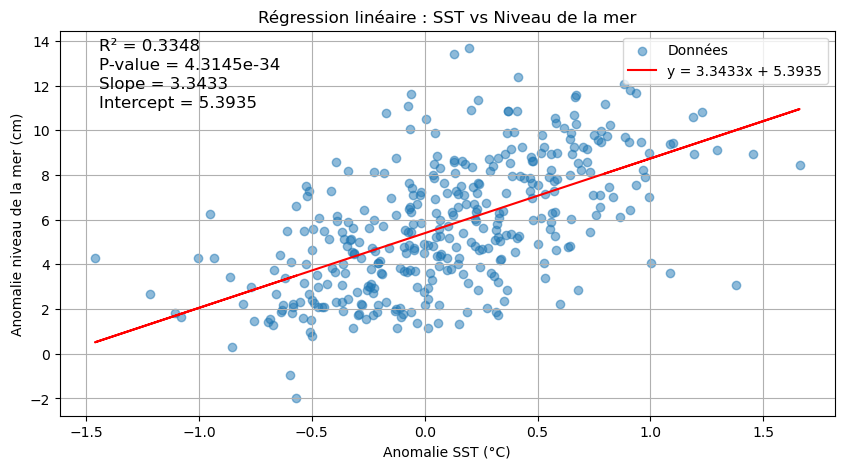

Slope: 3.3432773503187896
Intercept: 5.393471906052584
R-squared: 0.3347895092109203


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


sst_file = 'my_data_folder/sst_folder/sst_medsea_omi_tempsal_sst_area_averaged_monthly_anomalies_19820101-20231231_R19912020_P202405061.csv'
sea_level_file = 'my_data_folder/sea_level_folder/sea_level_monthly/sea_level_monthly.csv'
df_sst = pd.read_csv(sst_file, parse_dates=['time'])  # colonne 'time' obligatoire
df_sea = pd.read_csv(sea_level_file, parse_dates=['time'])

df_sst = df_sst[['time', 'sst_anomaly']]  # adapte le nom de la colonne si nécessaire
df_sea = df_sea[['time', 'MSL_filtered_GIA_TPA_corrected_adjusted']]  # idem ici

# Extraire année et mois
df_sst['year'] = df_sst['time'].dt.year
df_sst['month'] = df_sst['time'].dt.month

df_sea['year'] = df_sea['time'].dt.year
df_sea['month'] = df_sea['time'].dt.month

df_sst = df_sst[['year', 'month', 'sst_anomaly']]
df_sea = df_sea[['year', 'month', 'MSL_filtered_GIA_TPA_corrected_adjusted']]

# Fusionner sur (année, mois)
df_merged = pd.merge(df_sst, df_sea, on=['year', 'month'], how='inner')
df_merged = df_merged.dropna()

# Afficher un aperçu
print(df_merged.head())
print(f"Période : {df_merged['year'].min()}-{df_merged['month'].min():02d} à {df_merged['year'].max()}-{df_merged['month'].max():02d}")
print(f"Nombre de points : {len(df_merged)}")

x = df_merged['sst_anomaly'].values# données pour la régression
y = df_merged['MSL_filtered_GIA_TPA_corrected_adjusted'].values# données pour la régression

slope, intercept, r_value, p_value, std_err = linregress(x, y)# Régression linéaire

# Affichage
plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.5, label='Données')
plt.plot(x, slope * x + intercept, color='red', label=f'y = {slope:.4f}x + {intercept:.4f}')

# Infos de la régression sur le graphique
plt.text(0.05, 0.95, f'R² = {r_value**2:.4f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.90, f'P-value = {p_value:.4e}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.85, f'Slope = {slope:.4f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.80, f'Intercept = {intercept:.4f}', transform=plt.gca().transAxes, fontsize=12)

# Finitions
plt.title("Régression linéaire : SST vs Niveau de la mer")
plt.xlabel("Anomalie SST (°C)")
plt.ylabel("Anomalie niveau de la mer (cm)")
plt.legend()
plt.grid()
plt.show()

# Résultats numériques
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")


**Variable chlorophylle : régression linéaire simple sur le niveau de la mer**

   year  month   chlor_a  MSL_filtered_GIA_TPA_corrected_adjusted
3  1997      9  0.053407                                 3.383698
4  1997     10  0.056052                                 4.740028
5  1997     11  0.077832                                 6.090096
6  1997     12  0.115609                                 6.446326
7  1998      1  0.120509                                 5.709400
Période : 1997-01 à 2023-12
Nombre de points : 310


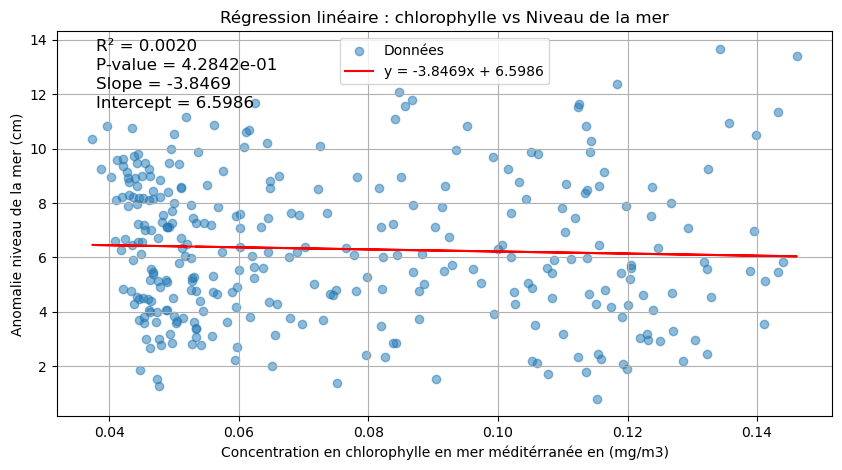

Slope: -3.8469203269778007
Intercept: 6.598610571014182
R-squared: 0.0020373067443077222


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


chl_file = 'my_data_folder/chl_folder/omi_health_chl_medsea_oceancolour_area_averaged_mean_19970901_P20240708.csv'
sea_level_file = 'my_data_folder/sea_level_folder/sea_level_monthly/sea_level_monthly.csv'
df_chl = pd.read_csv(chl_file, parse_dates=['time'])  # colonne 'time' obligatoire
df_sea = pd.read_csv(sea_level_file, parse_dates=['time'])

df_chl= df_chl[['time', 'chlor_a']]  # adapte le nom de la colonne si nécessaire
df_sea = df_sea[['time', 'MSL_filtered_GIA_TPA_corrected_adjusted']]  # idem ici

# Extraire année et mois
df_chl['year'] = df_chl['time'].dt.year
df_chl['month'] = df_chl['time'].dt.month

df_sea['year'] = df_sea['time'].dt.year
df_sea['month'] = df_sea['time'].dt.month

df_chl = df_chl[['year', 'month', 'chlor_a']]
df_sea = df_sea[['year', 'month', 'MSL_filtered_GIA_TPA_corrected_adjusted']]

# Fusionner sur (année, mois)
df_merged = pd.merge(df_chl, df_sea, on=['year', 'month'], how='inner')
df_merged = df_merged.dropna()

# Afficher un aperçu
print(df_merged.head())
print(f"Période : {df_merged['year'].min()}-{df_merged['month'].min():02d} à {df_merged['year'].max()}-{df_merged['month'].max():02d}")
print(f"Nombre de points : {len(df_merged)}")

x = df_merged['chlor_a'].values# données pour la régression
y = df_merged['MSL_filtered_GIA_TPA_corrected_adjusted'].values# données pour la régression

slope, intercept, r_value, p_value, std_err = linregress(x, y)# Régression linéaire

# Affichage
plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.5, label='Données')
plt.plot(x, slope * x + intercept, color='red', label=f'y = {slope:.4f}x + {intercept:.4f}')

# Infos de la régression sur le graphique
plt.text(0.05, 0.95, f'R² = {r_value**2:.4f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.90, f'P-value = {p_value:.4e}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.85, f'Slope = {slope:.4f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.80, f'Intercept = {intercept:.4f}', transform=plt.gca().transAxes, fontsize=12)

# Finitions
plt.title("Régression linéaire : chlorophylle vs Niveau de la mer")
plt.xlabel("Concentration en chlorophylle en mer méditérranée en (mg/m3)")
plt.ylabel("Anomalie niveau de la mer (cm)")
plt.legend()
plt.grid()
plt.show()

# Résultats numériques
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")